In [17]:
#import librarys


import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [2]:
df=pd.read_csv("divar.csv")

C:\Users\Amin\AppData\Local\Temp\ipykernel_9804\176574747.py:1: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("divar.csv")


In [3]:
df.describe()

,Unnamed: 0,rent_value,price_value,credit_value,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,regular_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
count,1000000.000000,3.513220e+05,5.683460e+05,3.520950e+05,3.520850e+05,7.240900e+04,3.512480e+05,7.240900e+04,1.863960e+05,9.803940e+05,29870.000000,1.024100e+04,1.806800e+04,1.046300e+04,1.355100e+04,655608.000000,655608.000000,339699.000000
mean,499999.500000,4.102299e+10,1.736537e+10,4.872084e+10,4.872222e+10,8.557025e+09,4.103164e+10,1.619934e+07,4.165480e+03,4.440648e+03,6.557650,1.209785e+10,1.389016e+11,2.355548e+10,3.156551e+10,34.982108,51.629743,465.149147
std,288675.278932,3.807534e+12,5.878739e+11,4.341346e+12,4.341407e+12,2.064576e+12,3.807935e+12,5.217890e+07,1.218927e+05,1.367118e+05,7.698655,1.103482e+12,7.042335e+12,1.542049e+12,2.434942e+12,2.379169,3.160920,125.896250
min,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,23.626478,40.162369,0.000000
25%,249999.750000,1.111110e+05,1.400000e+09,1.000000e+08,1.000000e+08,2.000000e+08,1.111110e+05,1.000000e+06,1.100000e+02,7.500000e+01,3.000000,5.000000e+04,4.000000e+05,6.000000e+05,5.500000e+05,34.553551,50.677175,500.000000
50%,499999.500000,5.000000e+06,2.840000e+09,2.500000e+08,2.500000e+08,4.000000e+08,5.000000e+06,6.000000e+06,1.950000e+02,1.030000e+02,4.000000,1.000000e+05,8.000000e+05,1.200000e+06,1.100000e+06,35.723312,51.345791,500.000000
75%,749999.250000,1.200000e+07,5.900000e+09,5.000000e+08,5.000000e+08,8.500000e+08,1.200000e+07,1.500000e+07,2.800000e+02,1.650000e+02,7.000000,2.000000e+05,1.600000e+06,2.500000e+06,2.500000e+06,36.307013,51.805291,500.000000
max,999999.000000,1.000000e+15,1.000000e+14,1.000000e+15,1.000000e+15,5.555556e+14,1.000000e+15,3.000000e+09,1.000000e+07,1.000000e+07,50.000000,1.111111e+14,5.006007e+14,1.111111e+14,2.002503e+14,40.358055,74.511620,500.000000


In [4]:
df["building_size"].dtype

df["construction_year"].dtype

construction_year = df["construction_year"].head()

build_size = df["building_size"].head()



none_empty = df["construction_year"].dropna()



In [5]:
construction_year_clean=df["construction_year"].str.translate(
    str.maketrans("۰۱۲۳۴۵۶۷۸۹", "0123456789"))    

construction_year_numeric = pd.to_numeric(
    construction_year_clean,
    errors="coerce"
)
numeric_count = construction_year_numeric.notna().sum()
non_numeric_count = construction_year_numeric.isna().sum()


non_numeric = df.loc[
    df["construction_year"].notna() & construction_year_numeric.isna(),
    "construction_year"
]



In [6]:
construction_group=pd.Series("unknown", df.index)

construction_group.loc[construction_year_numeric <1396]="old"

construction_group.loc[construction_year_numeric >=1396]="new"
construction_group.loc[
    df["construction_year"].notna() & construction_year_numeric.isna()
] = "old"

construction_group.value_counts()

old        412528
new        403300
unknown    184172
Name: count, dtype: int64

In [7]:
old_houses = df[construction_group == "old"]

new_houses = df[construction_group == "new"]

old_houses["building_size"].mean()


new_houses["building_size"].mean()

old_houses["building_size"].median()

new_houses["building_size"].median()

np.float64(105.0)

In [8]:
new_houses["building_size"].nlargest(20)

old_houses["building_size"].nlargest(20)

27686     10000000.0
167125    10000000.0
170378    10000000.0
229017    10000000.0
253874    10000000.0
317023    10000000.0
351669    10000000.0
356537    10000000.0
363843    10000000.0
374610    10000000.0
452440    10000000.0
475648    10000000.0
480312    10000000.0
517281    10000000.0
519074    10000000.0
523708    10000000.0
526313    10000000.0
534250    10000000.0
535334    10000000.0
543158    10000000.0
Name: building_size, dtype: float64

In [9]:
(new_houses["building_size"] == 10000000).sum()

(old_houses["building_size"] == 10000000).sum()

np.int64(28)

In [10]:
old_houses["building_size"].quantile([0.95, 0.99, 0.999])

new_houses["building_size"].quantile([0.95, 0.99, 0.999])

0.950       330.0
0.990      3500.0
0.999    600703.0
Name: building_size, dtype: float64

In [11]:
old_houses_filtered = old_houses[
    old_houses["building_size"] <= 10000
]

new_houses_filtered = new_houses[
    new_houses["building_size"] <= 10000
]

old_mean = old_houses_filtered["building_size"].mean()
old_median = old_houses_filtered["building_size"].median()

new_mean = new_houses_filtered["building_size"].mean()
new_median = new_houses_filtered["building_size"].median()

old_count_before = old_houses["building_size"].notna().sum()
new_count_before = new_houses["building_size"].notna().sum()

old_count_after = old_houses_filtered["building_size"].notna().sum()
new_count_after = new_houses_filtered["building_size"].notna().sum()

old_removed = old_count_before - old_count_after
new_removed = new_count_before - new_count_after



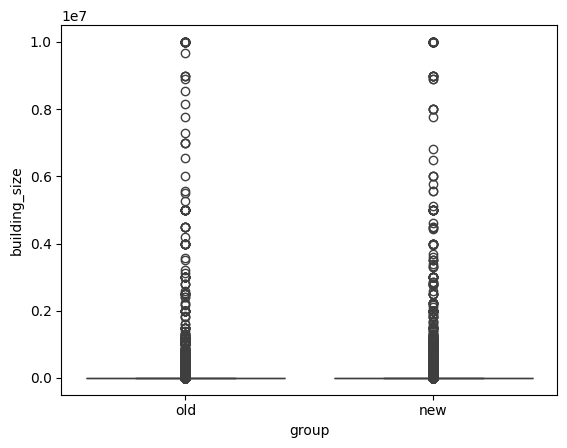

In [ ]:
old_plot = old_houses[["building_size"]].copy()
old_plot["group"] = "old"

new_plot = new_houses[["building_size"]].copy()
new_plot["group"] = "new"

plot_data = pd.concat([old_plot, new_plot])

sns.boxplot(data=plot_data, x="group", y="building_size")
plt.show()


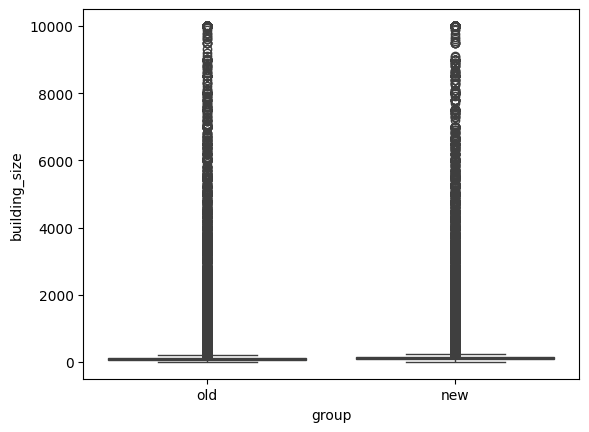

In [ ]:
old_plot_filtered = old_houses_filtered[["building_size"]].copy()
old_plot_filtered["group"] = "old"

new_plot_filtered = new_houses_filtered[["building_size"]].copy()
new_plot_filtered["group"] = "new"

plot_data_filtered = pd.concat([
    old_plot_filtered,
    new_plot_filtered
])

sns.boxplot(
    data=plot_data_filtered,
    x="group",
    y="building_size"
)
plt.show()


In [22]:
test = stats.ttest_ind(
    old_houses["building_size"].dropna(),
    new_houses["building_size"].dropna(),
    equal_var=False,
    alternative="greater"
)

print(test)

TtestResult(statistic=np.float64(-2.021856179663078), pvalue=np.float64(0.9784042296465262), df=np.float64(808305.1052065337))


In [30]:
old_data_filtered = old_houses_filtered["building_size"].dropna()
new_data_filtered = new_houses_filtered["building_size"].dropna()

test_filtered = stats.ttest_ind(
    old_data_filtered,
    new_data_filtered,
    equal_var=False,
    alternative="greater"
)

print(test_filtered)



TtestResult(statistic=np.float64(-25.33333424571378), pvalue=np.float64(1.0), df=np.float64(808564.4258245167))


برای بررسی این فرض که میانگین زیربنای خانه‌های قدیمی‌ساخت بیشتر از خانه‌های جدیدساخت است، از آزمون t مستقل ولچ و آزمون یک‌طرفه استفاده شد.
در داده‌های خام، میانگین زیربنای خانه‌های قدیمی‌ساخت برابر با 2758.67 و میانگین زیربنای خانه‌های جدیدساخت برابر با 3278.33 به دست آمد. آماره آزمون 2.02- و مقدار p برابر با 0.9784 بود. با توجه به اینکه مقدار p بزرگ‌تر از سطح معنی‌داری 0.05 است، فرض صفر رد نمی‌شود و شواهد آماری کافی برای تأیید این فرض که میانگین زیربنای خانه‌های قدیمی‌ساخت بیشتر از خانه‌های جدیدساخت است، وجود ندارد. همچنین مقایسه میانگین‌ها نشان می‌دهد که در نمونه مورد بررسی، میانگین زیربنای خانه‌های جدیدساخت بیشتر است.
برای بررسی تأثیر مقادیر بسیار بزرگ زیربنا بر نتیجه، تحلیل با فیلتر building_size <= 10000 نیز تکرار شد. در این حالت، میانگین زیربنای خانه‌های قدیمی‌ساخت 138.59 و میانگین خانه‌های جدیدساخت 162.95 به دست آمد. آماره آزمون 25.33- و مقدار p برابر با 1.0000 بود. بنابراین در تحلیل فیلترشده نیز فرض صفر رد نمی‌شود و نتیجه همچنان در خلاف جهت فرض پژوهشی قرار دارد.
در مجموع، هر دو تحلیل نشان می‌دهند که داده‌های این نمونه از فرض «بیشتر بودن میانگین زیربنای خانه‌های قدیمی‌ساخت» پشتیبانی نمی‌کنند. این نتیجه هم در داده‌های خام و هم پس از حذف مقادیر بسیار بزرگ‌تر از 10000 حفظ شده است؛ بنابراین اعمال این فیلتر تغییری در جهت نتیجه آزمون ایجاد نکرده است.